<a href="https://colab.research.google.com/github/abrishkhanzai441-arch/project.py/blob/main/open_cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install ultralytics
!pip install opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 6.4 MB/s eta 0:00:00


In [9]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLOv8n model
model = YOLO("yolov8n.pt")

# Display model information (optional)
model.info()

# Train the model on the COCO8 example dataset for 100 epochs
results = model.train(data="coco8.yaml", epochs=100, imgsz=640)

# Run inference with the YOLOv8n model on the 'oppo.webp' image
results = model("oppo.webp")

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs
Ultralytics 8.4.159 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=

In [ ]:
result =model(source="14350696_3840_2160_60fps.mp4" , save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/2250) /content/14350696_3840_2160_60fps.mp4: 384x640 (no detections), 115.8ms
video 1/1 (frame 2/2250) /content/14350696_3840_2160_60fps.mp4: 384x640 (no detections), 107.6ms
video 1/1 (frame 3/2250) /content/14350696_3840_2160_60fps.mp4: 384x640 (no detections), 97.1ms
video 1/1 (frame 4/2250) /content/14350696_3840_2160_60fps.mp4: 384x640 (no detections), 113.9ms
video 1/1 (frame 5/2250) /content/14350696_3840_2160_60fps.mp4: 384x640 

In [ ]:
from ultralytics import YOLO

# 1. Initialize the model
model = YOLO('yolov8n.pt')

# 2. Run detection on the video at 640p resolution
results = model.predict(
    source="14350696_3840_2160_60fps.mp4",
    save=True,
    imgsz=640,
    conf=0.25
)

In [1]:
import cv2
from ultralytics import YOLO

# 1. Load the model
model = YOLO('yolov8n.pt')

# 2. Input and output settings
video_path = "14350696_3840_2160_60fps.mp4"
output_path = "output_detected.avi"

cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS)) or 60

# Setup video writer (using XVID for stability in Colab)
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter(output_path, fourcc, fps // 2, (640, 360))  # Adjust FPS for skipped frames

frame_count = 0
print("Processing video... Please wait.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    # Process every 2nd frame to double performance speed
    if frame_count % 2 != 0:
        continue

    # Resize frame to 640p for fast inference
    resized_frame = cv2.resize(frame, (640, 360))

    # Run YOLO detection with stream=True and imgsz=640
    results = model(resized_frame, imgsz=640, conf=0.25, verbose=False)

    # Render bounding boxes onto frame
    annotated_frame = results[0].plot()

    # Save frame to output video
    out.write(annotated_frame)

    if frame_count % 200 == 0:
        print(f"Processed {frame_count} frames...")

cap.release()
out.release()
print(f"Done! Output saved to: {output_path}")

Processing video... Please wait.
Processed 200 frames...
Processed 400 frames...
Processed 600 frames...
Processed 800 frames...
Processed 1000 frames...
Processed 1200 frames...
Processed 1400 frames...
Processed 1600 frames...
Processed 1800 frames...
Processed 2000 frames...
Processed 2200 frames...
Done! Output saved to: output_detected.avi


Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

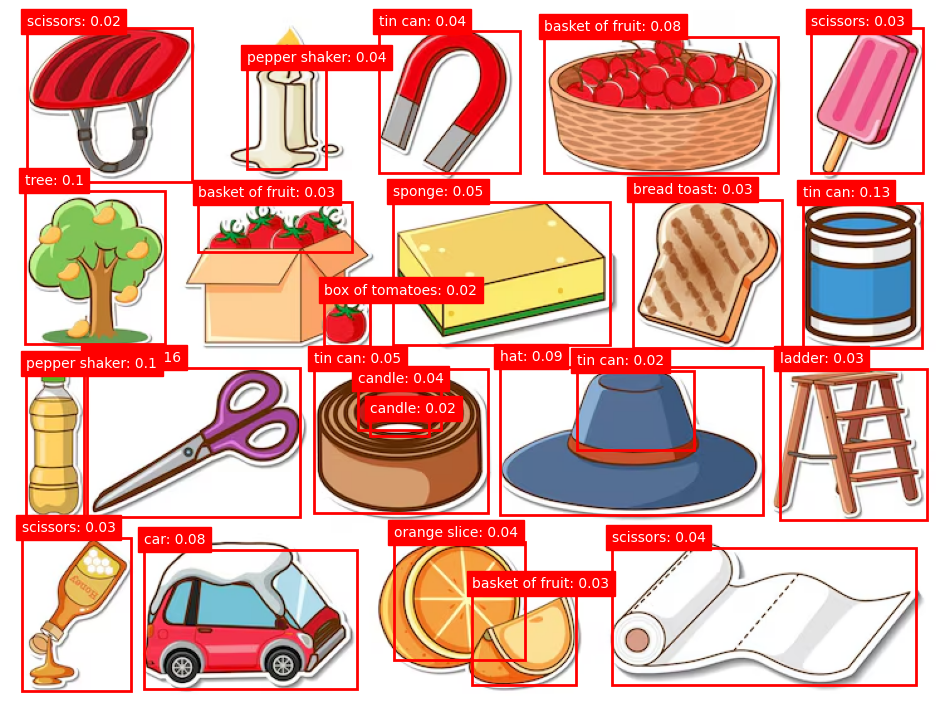

In [ ]:
!pip install -q transformers torch pillow ftfy regex torchvision

import torch
from PIL import Image
from transformers import OwlViTProcessor, OwlViTForObjectDetection
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.ops import nms

# 1. Load Model & Processor
processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")

# 2. Exact item descriptions
text_queries = [
    "helmet", "candle", "magnet", "basket of fruit", "popsicle",
    "tree", "box of tomatoes", "sponge", "bread toast", "tin can",
    "pepper shaker", "scissors", "tape roll", "hat", "ladder",
    "turkey leg", "car", "orange slice", "paper towel roll"
]

# 3. Load Image
image_path = "every day .jpg"
image = Image.open(image_path).convert("RGB")

# 4. Predict
inputs = processor(text=[text_queries], images=image, return_tensors="pt")
outputs = model(**inputs)

target_sizes = torch.tensor([image.size[::-1]])
results = processor.image_processor.post_process_object_detection(
    outputs=outputs,
    target_sizes=target_sizes,
    threshold=0.02
)[0]

# 5. Apply NMS to remove overlapping duplicate boxes
boxes = results["boxes"]
scores = results["scores"]
labels = results["labels"]

if len(boxes) > 0:
    keep_indices = nms(boxes, scores, iou_threshold=0.3)
    boxes = boxes[keep_indices]
    scores = scores[keep_indices]
    labels = labels[keep_indices]

# 6. Plot cleanly
fig, ax = plt.subplots(1, figsize=(12, 12))
ax.imshow(image)

for box, score, label in zip(boxes, scores, labels):
    box = [round(i, 2) for i in box.tolist()]
    xmin, ymin, xmax, ymax = box
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.text(
        xmin, max(ymin - 5, 12),
        f"{text_queries[label]}: {round(score.item(), 2)}",
        color='white', backgroundcolor='red', fontsize=10
    )

plt.axis('off')
plt.show()

Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

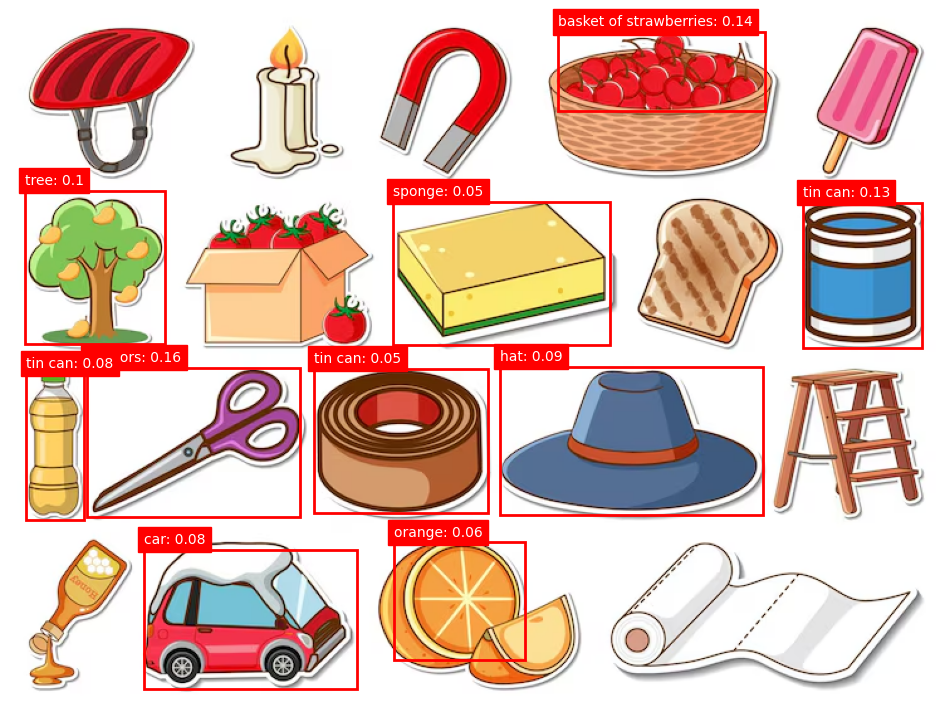

In [ ]:
!pip install -q transformers torch pillow ftfy regex torchvision

import torch
from PIL import Image
from transformers import OwlViTProcessor, OwlViTForObjectDetection
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.ops import nms

# 1. Load Model
processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")

# 2. STRICT list of ONLY the items clearly visible in the image
text_queries = [
    "helmet", "magnet", "tree", "sponge", "toast",
    "tin can", "scissors", "roll of tape", "hat", "ladder",
    "car", "orange", "paper towel roll", "basket of strawberries"
]

# 3. Load Image
image_path = "every day .jpg"
image = Image.open(image_path).convert("RGB")

# 4. Run Model
inputs = processor(text=[text_queries], images=image, return_tensors="pt")
outputs = model(**inputs)

target_sizes = torch.tensor([image.size[::-1]])

# 5. Higher threshold (0.05) to filter out wrong guesses and keep high-confidence detections
results = processor.image_processor.post_process_object_detection(
    outputs=outputs,
    target_sizes=target_sizes,
    threshold=0.05
)[0]

boxes = results["boxes"]
scores = results["scores"]
labels = results["labels"]

# 6. Apply NMS to remove duplicate boxes on the same object
if len(boxes) > 0
    keep = nms(boxes, scores, iou_threshold=0.3)
    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]

# 7. Display Results
fig, ax = plt.subplots(1, figsize=(12, 12))
ax.imshow(image)

for box, score, label in zip(boxes, scores, labels):
    box = [round(i, 2) for i in box.tolist()]
    xmin, ymin, xmax, ymax = box
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.text(
        xmin, max(ymin - 5, 12),
        f"{text_queries[label]}: {round(score.item(), 2)}",
        color='white', backgroundcolor='red', fontsize=10
    )

plt.axis('off')
plt.show()